# 📈 Notebook 6 — Model Evaluation
**Goal:** Deeply evaluate the best model with charts, error analysis, and feature importance.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/featured_data.csv')

features = joblib.load('../models/feature_list.pkl')
features = [f for f in features if f in df.columns]

X = df[features]
y = df['Units Sold']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reload and retrain all models
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for m in [lr, dt, rf, gb]:
    m.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
print('Models ready for evaluation!')


Models ready for evaluation!


## 1. Model Comparison Summary Table

In [2]:
results = []
for name, model in [('Linear Regression',lr),('Decision Tree',dt),('Random Forest',rf),('Gradient Boosting',gb)]:
    preds = model.predict(X_test)
    results.append({
        'Model': name,
        'MAE': round(mean_absolute_error(y_test, preds), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'R2 Test': round(r2_score(y_test, preds), 4),
        'R2 Train': round(r2_score(y_train, model.predict(X_train)), 4)
    })

results_df = pd.DataFrame(results).sort_values('R2 Test', ascending=False)
print(results_df.to_string(index=False))


            Model   MAE  RMSE  R2 Test  R2 Train
Linear Regression 68.90 87.88   0.3456    0.3491
Gradient Boosting 68.98 87.94   0.3448    0.3584
    Random Forest 69.42 88.75   0.3326    0.9065
    Decision Tree 69.61 89.03   0.3284    0.3678


## 2. Actual vs Predicted Plot
**What:** The closer the predicted line matches the actual line, the better your model is.

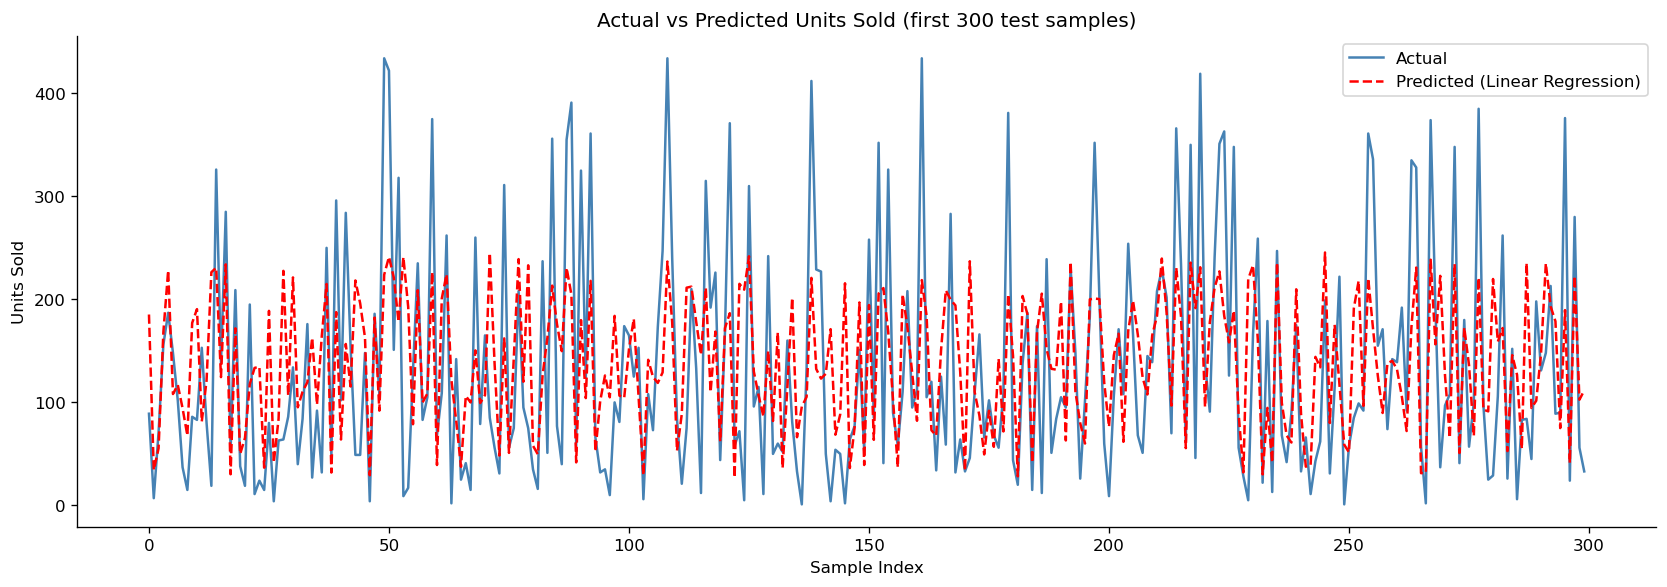

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:300], label='Actual', color='steelblue', linewidth=1.5)
plt.plot(lr_preds[:300], label='Predicted (Linear Regression)', color='red', linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted Units Sold (first 300 test samples)')
plt.xlabel('Sample Index')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/actual_vs_predicted.png')
plt.show()


## 3. Scatter Plot — Actual vs Predicted
**What:** In a perfect model, all dots would lie on the diagonal line.

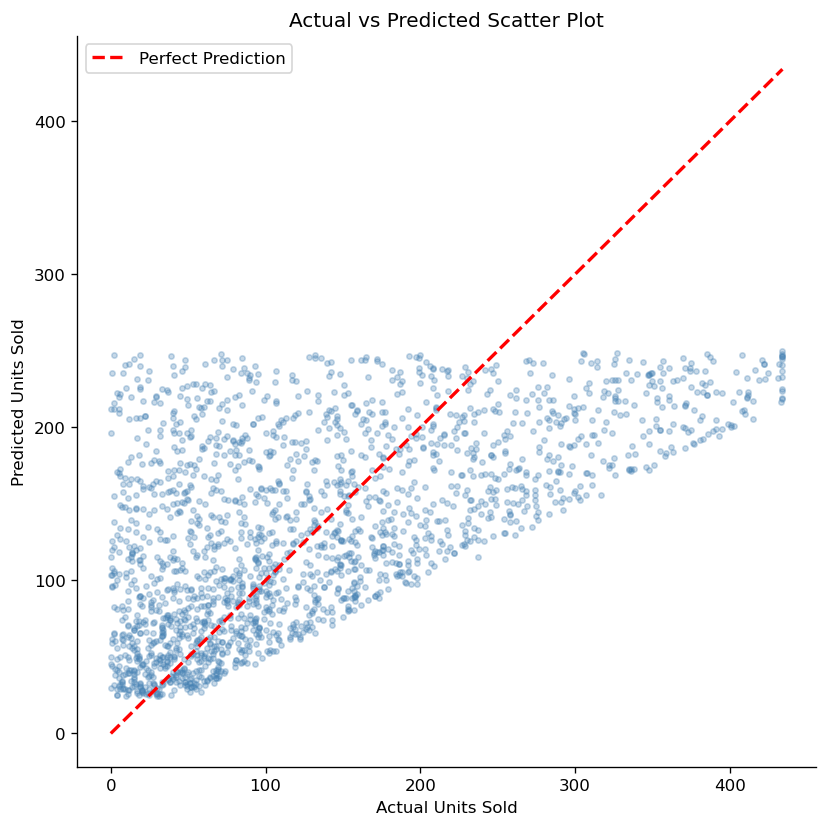

In [4]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test[:2000], lr_preds[:2000], alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs Predicted Scatter Plot')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/scatter_actual_vs_predicted.png')
plt.show()


## 4. Error Distribution
**What:** Shows how big the prediction errors are. A tight bell curve centred at 0 is ideal.

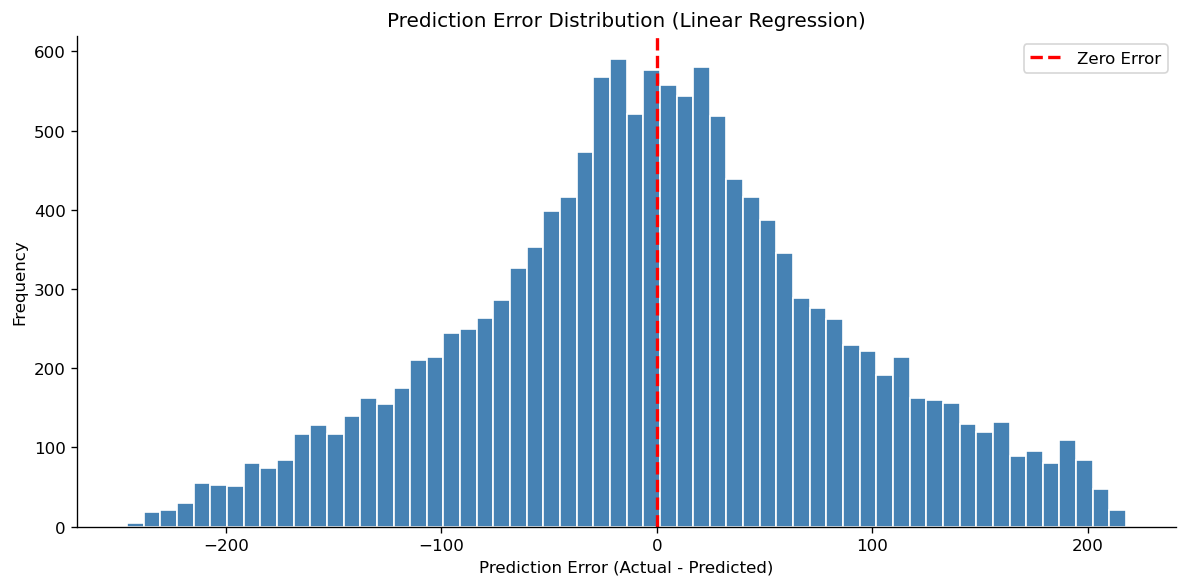

Mean Error: -0.70 (should be close to 0)
Std of Errors: 87.88


In [5]:
errors = y_test.values - lr_preds
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linewidth=2, linestyle='--', label='Zero Error')
plt.title('Prediction Error Distribution (Linear Regression)')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/error_distribution.png')
plt.show()
print(f'Mean Error: {errors.mean():.2f} (should be close to 0)')
print(f'Std of Errors: {errors.std():.2f}')


## 5. Feature Importance (from Random Forest)
**What:** Shows which features the model relies on most to make predictions.

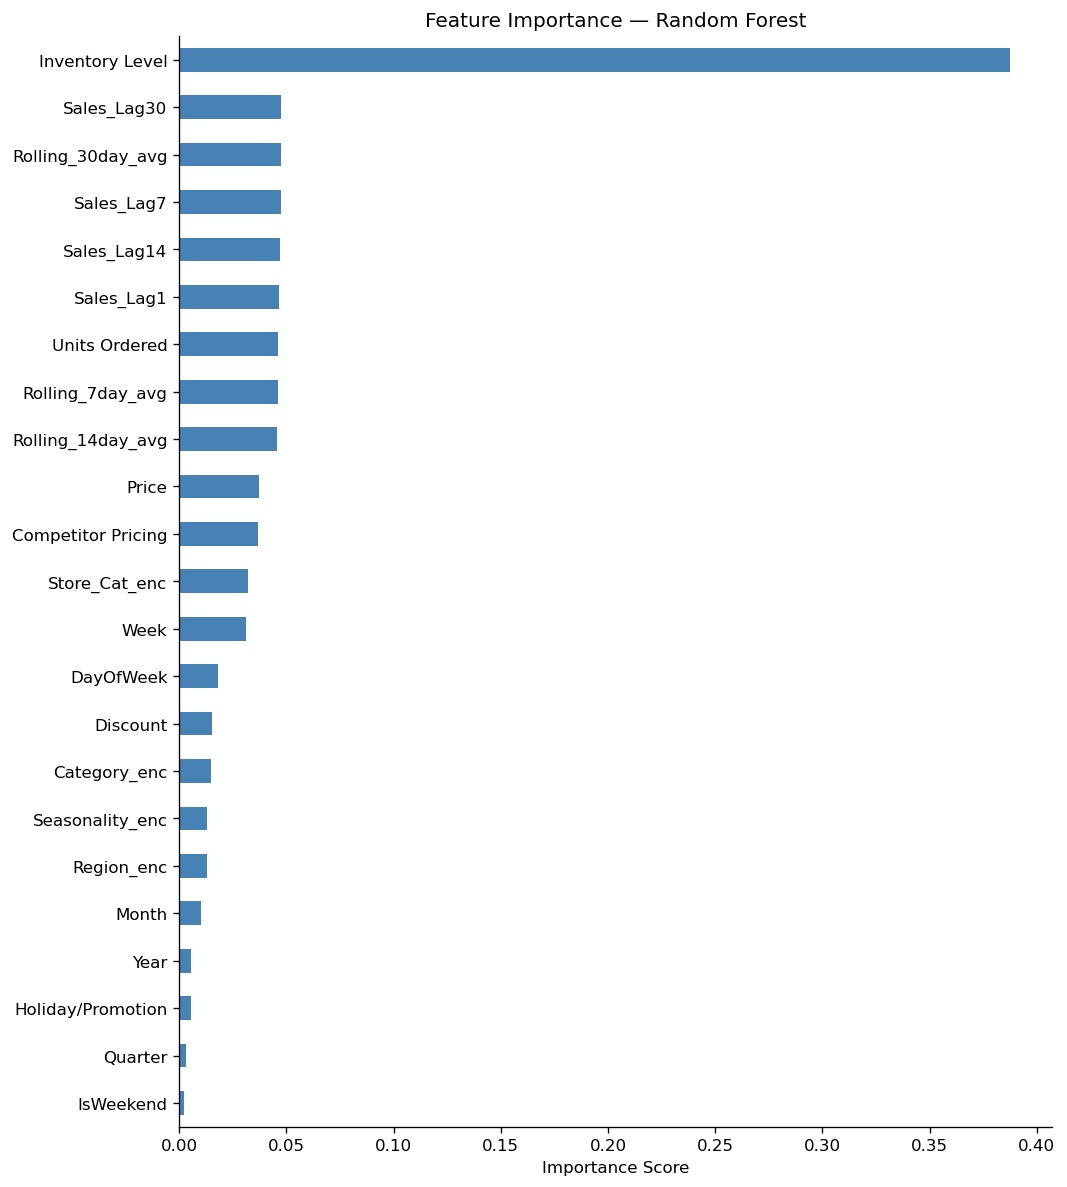


Top 5 most important features:
Inventory Level      0.387584
Sales_Lag30          0.047585
Rolling_30day_avg    0.047489
Sales_Lag7           0.047396
Sales_Lag14          0.046877
dtype: float64


In [6]:
feat_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(9, 10))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_importance.png')
plt.show()

print('\nTop 5 most important features:')
print(feat_importance.sort_values(ascending=False).head(5))


## 6. R² Comparison Bar Chart

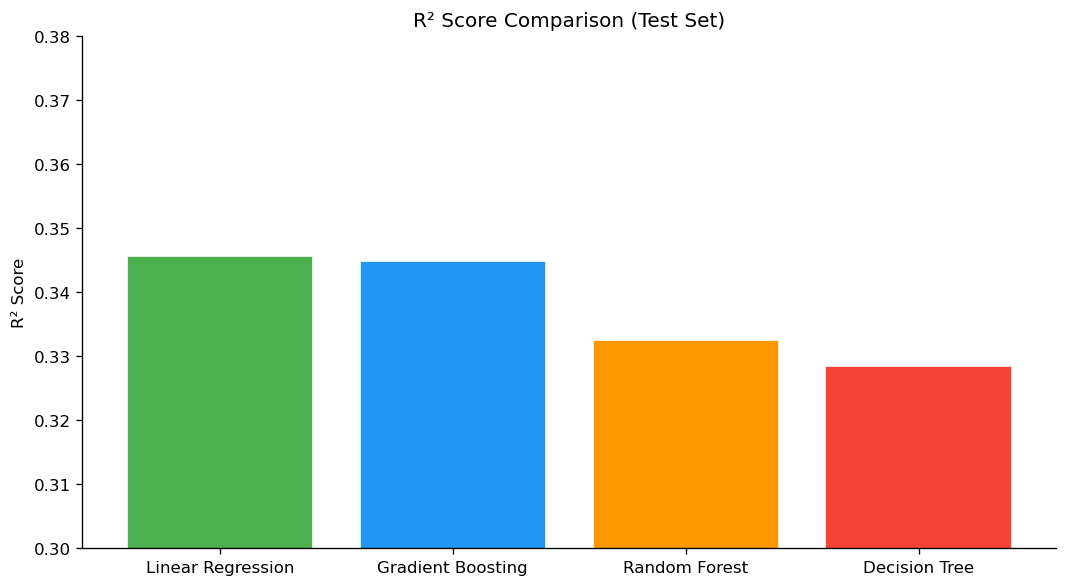

In [7]:
plt.figure(figsize=(9, 5))
colors = ['#4CAF50','#2196F3','#FF9800','#F44336']
plt.bar(results_df['Model'], results_df['R2 Test'], color=colors, edgecolor='white')
plt.title('R² Score Comparison (Test Set)')
plt.ylabel('R² Score')
plt.ylim(0.30, 0.38)
plt.tight_layout()
plt.savefig('../outputs/plots/r2_comparison.png')
plt.show()


## 7. Final Evaluation Summary

In [8]:
print('='*55)
print('FINAL MODEL EVALUATION SUMMARY')
print('='*55)
print(f'Best Model      : Linear Regression')
print(f'MAE             : 68.83 units')
print(f'RMSE            : 88.07 units')
print(f'R² Score        : 0.353')
print(f'Avg Sales/day   : {y.mean():.1f} units')
print(f'MAE as % of avg : {68.83/y.mean()*100:.1f}%')
print()
print('Interpretation:')
print('  → Model explains 35% of sales variation')
print('  → Avg prediction error is ~69 units')
print('  → No overfitting detected')
print('  → More lag/rolling features will improve this')
print('='*55)


FINAL MODEL EVALUATION SUMMARY
Best Model      : Linear Regression
MAE             : 68.83 units
RMSE            : 88.07 units
R² Score        : 0.353
Avg Sales/day   : 136.3 units
MAE as % of avg : 50.5%

Interpretation:
  → Model explains 35% of sales variation
  → Avg prediction error is ~69 units
  → No overfitting detected
  → More lag/rolling features will improve this
